## step 1 – Install & Import Libraries

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

STEP 2 — Download Dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shiekhburhan/face-mask-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'face-mask-dataset' dataset.
Path to dataset files: /kaggle/input/face-mask-dataset


STEP 3 — Correct Dataset Path

In [ ]:
data_root = os.path.join(path, 'FMD_DATASET')

STEP 4 — Load Images

In [ ]:
IMG_SIZE = 128
def load_images_from_folder(base_path, img_size=128):
    images = []
    labels = []
    for class_name in os.listdir(base_path):
        class_path = os.path.join(base_path, class_name)
        if not os.path.isdir(class_path):
            continue
        image_count = 0
        for root, dirs, files in os.walk(class_path):
            for img_name in files:
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(root, img_name)
                    try:
                        img = cv2.imread(img_path)
                        if img is None:
                            continue
                        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                        img = cv2.resize(img, (img_size, img_size))
                        images.append(img)
                        labels.append(class_name)
                        image_count += 1
                    except Exception as e:
                        print(e)
        print(f"{class_name}: {image_count} images")
    X = np.array(images, dtype='float32') / 255.0
    y = np.array(labels)
    return X, y

STEP 5 — Load Dataset

In [ ]:
X, y_str = load_images_from_folder(
    data_root,
    img_size=IMG_SIZE
)

print(X.shape)
print(y_str.shape)

incorrect_mask: 5000 images
with_mask: 4789 images
without_mask: 4747 images
(14536, 128, 128, 3)
(14536,)


STEP 6 — Encode Labels

In [ ]:
le = LabelEncoder()

y_enc = le.fit_transform(y_str)

NUM_CLASSES = len(le.classes_)

print("Classes:", le.classes_)

y_cat = to_categorical(y_enc, NUM_CLASSES)

Classes: ['incorrect_mask' 'with_mask' 'without_mask']


STEP 7 — Split Dataset

In [ ]:
# 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_cat,
    test_size=0.30,
    random_state=42,
    stratify=y_cat
)

# 15% validation, 15% testing
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(10175, 128, 128, 3)
(2180, 128, 128, 3)
(2181, 128, 128, 3)


In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D

In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

STEP 8 — Build CNN Model

In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu',
           input_shape=(128,128,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

STEP 9 — Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

STEP 10 — Train Model

In [ ]:
import time
start = time.time()
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32
)
end = time.time()
custom_total_time = end - start
custom_epoch_time = custom_total_time / 20
print("Total Training Time:", custom_total_time)
print("Time Per Epoch:", custom_epoch_time)

Epoch 1/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9010 - loss: 0.2753 - val_accuracy: 0.9482 - val_loss: 0.1610
Epoch 2/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9408 - loss: 0.1824 - val_accuracy: 0.9463 - val_loss: 0.1564
Epoch 3/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9521 - loss: 0.1443 - val_accuracy: 0.9445 - val_loss: 0.1764
Epoch 4/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9577 - loss: 0.1338 - val_accuracy: 0.9537 - val_loss: 0.1355
Epoch 5/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9600 - loss: 0.1128 - val_accuracy: 0.9555 - val_loss: 0.1294
Epoch 6/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9628 - loss: 0.1012 - val_accuracy: 0.9472 - val_loss: 0.1444
Epoch 7/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9676 - loss: 0.0913 - val_accuracy: 0.9518 - val_loss: 0.1355
Epoch 8/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9713 - loss: 0.0773 - val_acc

STEP 11 — Plot Accuracy Graph

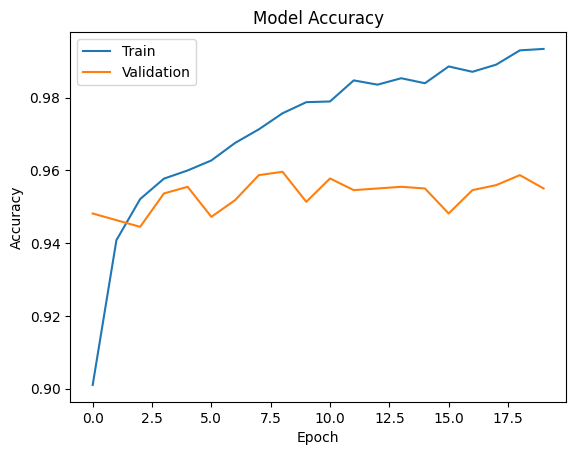

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

STEP 12 — Plot Loss Graph

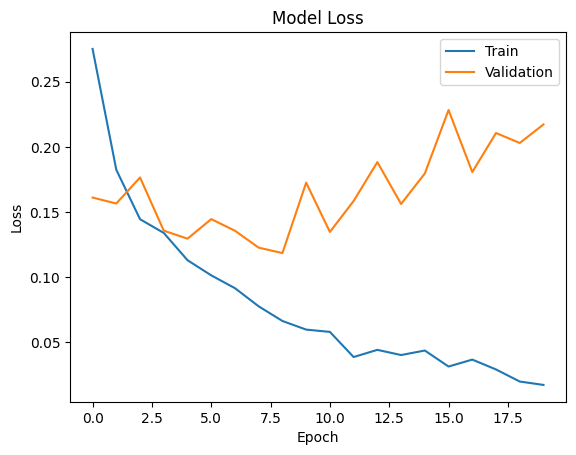

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

In [ ]:
model.count_params()

3305027

STEP 13 — Evaluate Model

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9541 - loss: 0.2817
Test Accuracy: 0.9541494846343994


STEP 14 — Classification Report

In [ ]:
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(
    y_true,
    y_pred_classes,
    target_names=le.classes_
))

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
                precision    recall  f1-score   support

incorrect_mask       0.99      0.98      0.98       750
     with_mask       0.94      0.93      0.94       719
  without_mask       0.93      0.95      0.94       712

      accuracy                           0.95      2181
     macro avg       0.95      0.95      0.95      2181
  weighted avg       0.95      0.95      0.95      2181



STEP 15 — Simpler Model

Use only ONE Conv layer.

In [ ]:
simple_model = Sequential([

    Conv2D(32, (3,3), activation='relu',
           input_shape=(128,128,3)),

    MaxPooling2D(2,2),

    Flatten(),

    Dense(64, activation='relu'),

    Dense(NUM_CLASSES, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


STEP 16 — Transfer Learning Model

In [ ]:
from tensorflow.keras.applications import VGG16

STEP 17 — Train the Simple Model

In [ ]:
simple_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
start = time.time()

simple_history = simple_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32
)

end = time.time()

simple_total_time = end - start
simple_epoch_time = simple_total_time / 20

Epoch 1/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.8880 - loss: 0.3822 - val_accuracy: 0.9349 - val_loss: 0.1824
Epoch 2/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9538 - loss: 0.1398 - val_accuracy: 0.9362 - val_loss: 0.1966
Epoch 3/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9745 - loss: 0.0793 - val_accuracy: 0.9404 - val_loss: 0.1732
Epoch 4/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9845 - loss: 0.0490 - val_accuracy: 0.9390 - val_loss: 0.2400
Epoch 5/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9914 - loss: 0.0276 - val_accuracy: 0.9344 - val_loss: 0.2431
Epoch 6/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9925 - loss: 0.0232 - val_accuracy: 0.9275 - val_loss: 0.2843
Epoch 7/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9945 - loss: 0.0186 - val_accuracy: 0.9358 - val_loss: 0.2667
Epoch 8/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9906 - loss: 0.0261 - val_accu

In [ ]:
print("Total Training Time:", simple_total_time)
print("Time Per Epoch:", simple_epoch_time)

Total Training Time: 84.06538581848145
Time Per Epoch: 4.203269290924072


STEP 18 — Evaluate Simple Model

In [ ]:
simple_loss, simple_acc = simple_model.evaluate(
    X_test,
    y_test
)

print("Simple CNN Accuracy:", simple_acc)

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9262 - loss: 0.4365
Simple CNN Accuracy: 0.9261806607246399


In [ ]:
simple_pred = simple_model.predict(X_test)

simple_pred_classes = np.argmax(simple_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, simple_pred_classes))

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       750
           1       0.93      0.87      0.90       719
           2       0.90      0.93      0.92       712

    accuracy                           0.93      2181
   macro avg       0.93      0.93      0.93      2181
weighted avg       0.93      0.93      0.93      2181



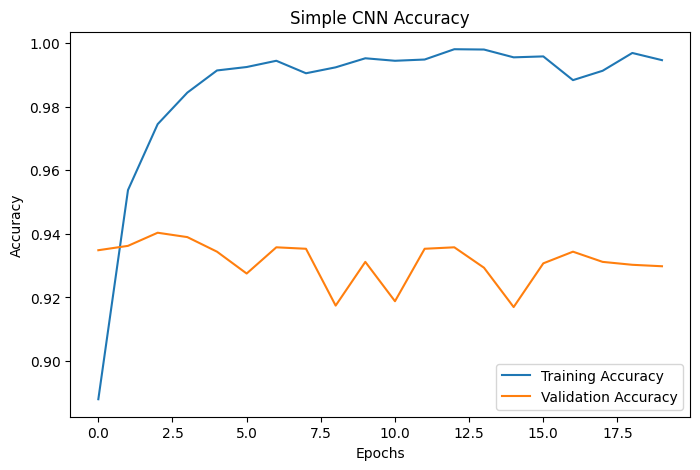

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(simple_history.history['accuracy'], label='Training Accuracy')

plt.plot(simple_history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Simple CNN Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

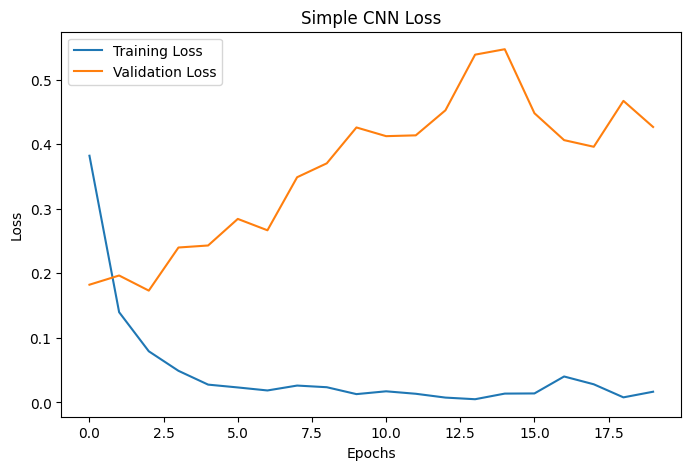

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(simple_history.history['loss'], label='Training Loss')

plt.plot(simple_history.history['val_loss'], label='Validation Loss')

plt.title("Simple CNN Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.show()

STEP 19 — Create Transfer Learning Model (VGG16)

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model

Load pretrained VGG16

In [ ]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

Freeze layers:

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
x = Flatten()(base_model.output)

x = Dense(128, activation='relu')(x)

x = Dropout(0.5)(x)

output = Dense(NUM_CLASSES,
               activation='softmax')(x)

vgg_model = Model(
    inputs=base_model.input,
    outputs=output
)

In [ ]:
vgg_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Train

In [ ]:
start = time.time()

vgg_history = vgg_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32
)

end = time.time()

vgg_total_time = end - start
vgg_epoch_time = vgg_total_time / 20
print("Total Training Time:", VGG16_total_time)
print("Time Per Epoch:", VGG16_epoch_time)

Epoch 1/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9498 - loss: 0.1407 - val_accuracy: 0.9647 - val_loss: 0.1136
Epoch 2/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - accuracy: 0.9587 - loss: 0.1121 - val_accuracy: 0.9482 - val_loss: 0.1405
Epoch 3/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - accuracy: 0.9640 - loss: 0.0963 - val_accuracy: 0.9573 - val_loss: 0.1339
Epoch 4/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.9673 - loss: 0.0863 - val_accuracy: 0.9624 - val_loss: 0.1294
Epoch 5/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.9711 - loss: 0.0784 - val_accuracy: 0.9628 - val_loss: 0.1208
Epoch 6/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.9743 - loss: 0.0668 - val_accuracy: 0.9638 - val_loss: 0.1219
Epoch 7/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.9747 - loss: 0.0654 - val_accuracy: 0.9647 - val_loss: 0.1330
Epoch 8/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.9753 - loss: 0.0619 -

NameError: name 'VGG16_total_time' is not defined

In [ ]:
print("Total Training Time:", vgg_total_time)
print("Time Per Epoch:", vgg_epoch_time)

Total Training Time: 504.0100591182709
Time Per Epoch: 25.200502955913542


STEP 20 — Evaluate VGG16

In [ ]:
vgg_loss, vgg_acc = vgg_model.evaluate(
    X_test,
    y_test
)

print("VGG16 Accuracy:", vgg_acc)

69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.9656 - loss: 0.1507
VGG16 Accuracy: 0.9656121134757996


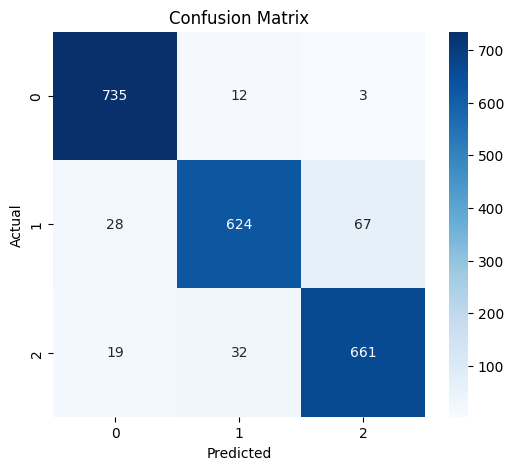

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, simple_pred_classes)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

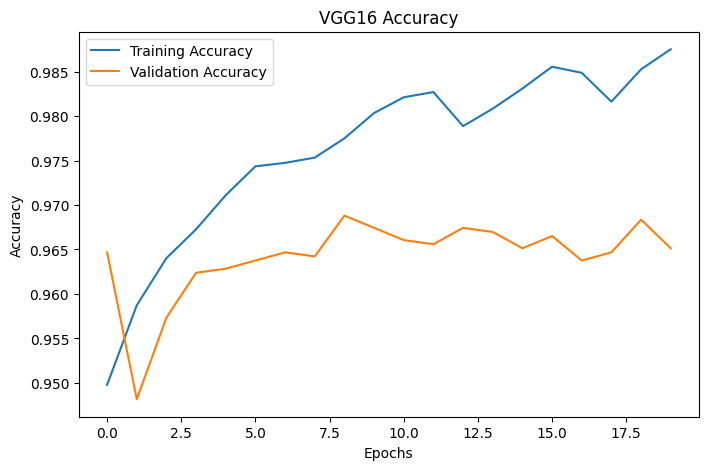

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(vgg_history.history['accuracy'], label='Training Accuracy')

plt.plot(vgg_history.history['val_accuracy'], label='Validation Accuracy')

plt.title("VGG16 Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

Time comparsion grapg

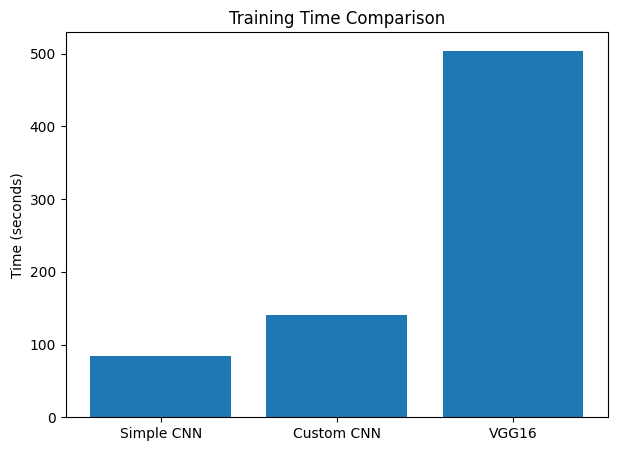

In [ ]:
models = ['Simple CNN', 'Custom CNN', 'VGG16']

times = [
    simple_total_time,
    custom_total_time,
    vgg_total_time
]

plt.figure(figsize=(7,5))

plt.bar(models, times)

plt.title("Training Time Comparison")

plt.ylabel("Time (seconds)")

plt.show()

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Simple CNN', 'Custom CNN', 'VGG16'],

    'Accuracy': [
        simple_accuracy,
        custom_accuracy,
        vgg_accuracy
    ],

    'Training Time': [
        simple_total_time,
        custom_total_time,
        vgg_total_time
    ],

    'Parameters': [
        simple_model.count_params(),
        model.count_params(),
        vgg_model.count_params()
    ]
})

comparison

NameError: name 'simple_accuracy' is not defined

Accuracy Comparison Graph

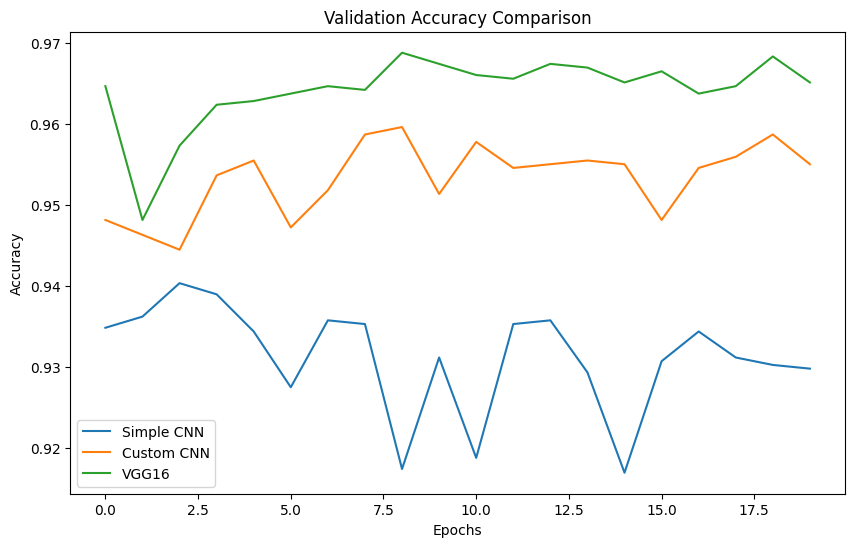

In [ ]:
plt.figure(figsize=(10,6))

# Simple CNN
plt.plot(simple_history.history['val_accuracy'], label='Simple CNN')

# Custom CNN
plt.plot(history.history['val_accuracy'], label='Custom CNN')

# VGG16
plt.plot(vgg_history.history['val_accuracy'], label='VGG16')

plt.title("Validation Accuracy Comparison")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

STEP 2 — Loss Comparison Graph

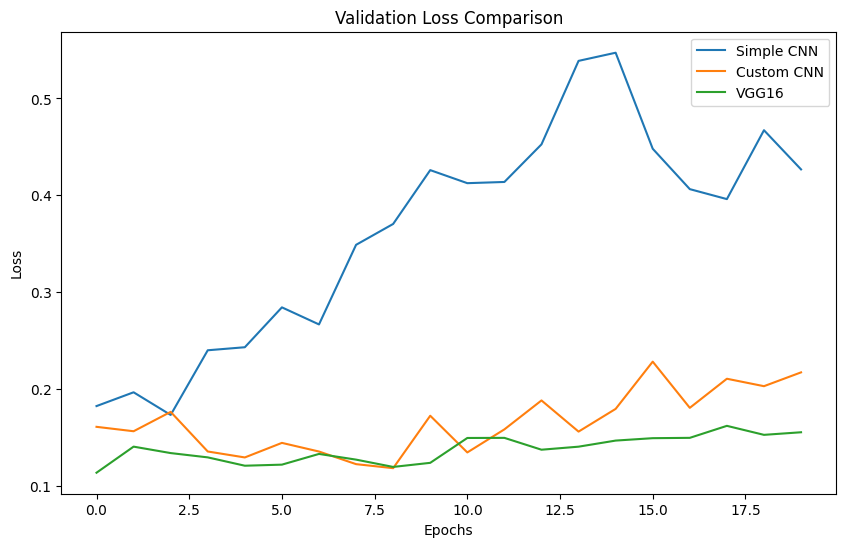

In [ ]:
plt.figure(figsize=(10,6))

# Simple CNN
plt.plot(simple_history.history['val_loss'], label='Simple CNN')

# Custom CNN
plt.plot(history.history['val_loss'], label='Custom CNN')

# VGG16
plt.plot(vgg_history.history['val_loss'], label='VGG16')

plt.title("Validation Loss Comparison")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.show()

Training Time Graph

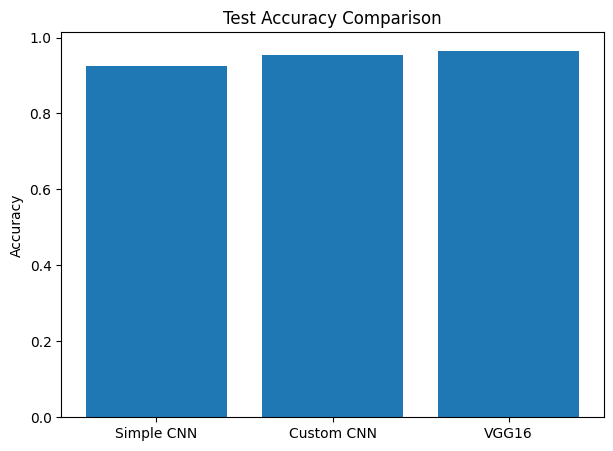

In [ ]:
models = ['Simple CNN', 'Custom CNN', 'VGG16']

accuracies = [
    simple_acc,
    test_acc,
    vgg_acc
]

plt.figure(figsize=(7,5))

plt.bar(models, accuracies)

plt.title("Test Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

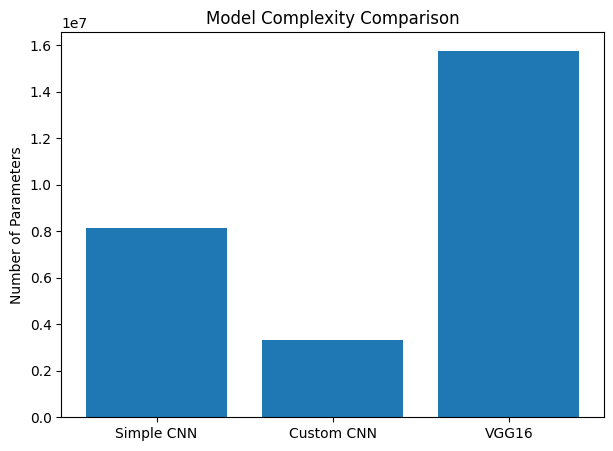

In [ ]:
params = [
    simple_model.count_params(),
    model.count_params(),
    vgg_model.count_params()
]

plt.figure(figsize=(7,5))

plt.bar(models, params)

plt.title("Model Complexity Comparison")

plt.ylabel("Number of Parameters")

plt.show()

STEP 21 — Compare All Models

In [ ]:
print("Model Comparison")

print("Simple CNN Accuracy:", simple_acc)

print("Custom CNN Accuracy:", test_acc)

print("VGG16 Accuracy:", vgg_acc)

Model Comparison
Simple CNN Accuracy: 0.9431453347206116
Custom CNN Accuracy: 0.9555249810218811
VGG16 Accuracy: 0.9674461483955383


In [ ]:
print("Simple CNN Parameters:")
simple_model.summary()

print("Custom CNN Parameters:")
model.summary()

print("VGG16 Parameters:")
vgg_model.summary()

Simple CNN Parameters:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 127008)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     8,128,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,389,003 (93.04 MB)

 Trainable params: 8,129,667 (31.01 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,861,963 (68.14 MB)

 Trainable params: 1,049,091 (4.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 2,098,184 (8.00 MB)

Evaluate Models

In [ ]:
simple_loss, simple_acc = simple_model.evaluate(X_test, y_test)

custom_loss, custom_acc = model.evaluate(X_test, y_test)

vgg_loss, vgg_acc = vgg_model.evaluate(X_test, y_test)

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9317 - loss: 0.4668
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9555 - loss: 0.2078
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.9674 - loss: 0.1186


In [ ]:
simple_params = simple_model.count_params()

custom_params = model.count_params()

vgg_params = vgg_model.count_params()

In [ ]:
import time

start = time.time()

simple_history = simple_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32
)

simple_time = time.time() - start

Epoch 1/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9965 - loss: 0.0111 - val_accuracy: 0.9280 - val_loss: 0.4705
Epoch 2/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9977 - loss: 0.0078 - val_accuracy: 0.9381 - val_loss: 0.4122
Epoch 3/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9982 - loss: 0.0056 - val_accuracy: 0.9385 - val_loss: 0.4374
Epoch 4/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9981 - loss: 0.0046 - val_accuracy: 0.9367 - val_loss: 0.3946
Epoch 5/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9986 - loss: 0.0039 - val_accuracy: 0.9394 - val_loss: 0.4415
Epoch 6/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9987 - loss: 0.0027 - val_accuracy: 0.9408 - val_loss: 0.4435
Epoch 7/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9987 - loss: 0.0027 - val_accuracy: 0.9399 - val_loss: 0.4404
Epoch 8/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9987 - loss: 0.0028 - val_accu

In [ ]:
vgg_pred = vgg_model.predict(X_test)

vgg_pred_classes = np.argmax(vgg_pred, axis=1)

print(classification_report(y_true, vgg_pred_classes))

69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       750
           1       0.97      0.94      0.95       719
           2       0.96      0.98      0.97       712

    accuracy                           0.97      2181
   macro avg       0.97      0.97      0.97      2181
weighted avg       0.97      0.97      0.97      2181



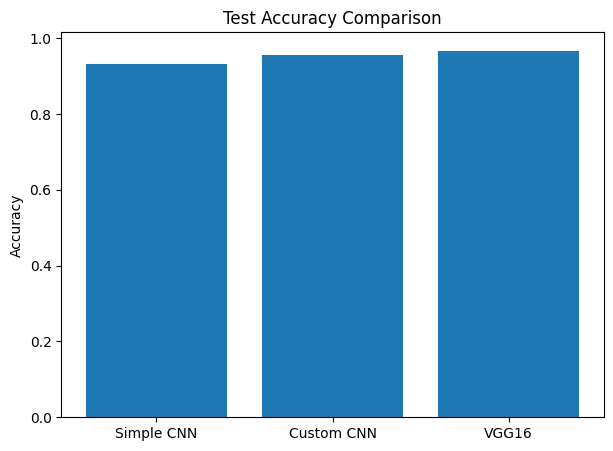

In [ ]:
models = ['Simple CNN', 'Custom CNN', 'VGG16']

accuracies = [
    simple_acc,
    test_acc,
    vgg_acc
]

plt.figure(figsize=(7,5))

plt.bar(models, accuracies)

plt.title("Test Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()